# cd_A_weakfaith: BIC 评分 vs 默认 L0 评分 (5-node ER1)

**目标**：在 5-node ER1 (s0=5 edges) 设定下，对比 `cd_A_weakfaith`（mask 方式固定为 `pcorr`）
在两种评分函数下的精度：

- **L0**：原始评分 `f(A,S) - λ_l0 · #edges`，`λ_l0 = 0.2` (默认)
- **BIC**：等价于 `f(A,S) - (penalty_discount · log n / n) · #edges`；这里 `f(A,S) = -2 log det(A) + tr(A^T S A)` 等于高斯线性 SEM 的 `-2/n × log L` (差常数)，所以加 `log(n)/n × #edges` 就是 BIC 惩罚

**两个样本量**：n ∈ {2000, 20000} —— 看 BIC 的 `log(n)/n` 自适应惩罚相对 L0 的固定 `λ` 在不同 n 上的表现。

其它参数（`tau=0.05, screening='pcorr', threshold=0.05, T=100K, early_stop=True, tol=1e-4`）固定不变。

CPDAG-SHD 通过 [`dag_metrics.cpdag_shd`](../../../dag_metrics.py) 计算 (causaldag 后端，与 paper 一致)。

## 1. 环境与配置

In [1]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for path in [start, *start.parents]:
        if (path / 'calm_dataset.py').exists() and (path / 'coordinate_descent').exists():
            return path
    raise RuntimeError(f'Could not find repo root from {start}')


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

from calm_dataset import CalmDataset, weight_to_binary_adj
from coordinate_descent.cd_A_weakfaith import dag_coordinate_descent_l0_weakfaith
from dag_metrics import cpdag_shd, shd_directed, evaluate, get_cpdag_shd_backend

print('Repo root            :', REPO_ROOT)
print('CPDAG-SHD backend    :', get_cpdag_shd_backend())

CFG = {
    'trials':       10,
    'seed':         42,
    'd':            50,
    'calm_degree':  2.0,         # ER1: s0 = round(2.0 * 50) = 100 edges
    'graph_type':   'ER',
    'n_list':       [2000, 20000],
    'sem_type':     'gauss',
    'noise_ratio':  16.0,
    'noise_scale_mode': 'variance',
    'b_scale':      1.0,
    # cd_A_weakfaith
    'cd_T':         500000,
    'cd_threshold': 0.05,
    'cd_lambda_l0': 0.2,         # used by score='l0'
    'penalty_discount': 1.0,     # used by score='bic'
    'wf_tau':       0.05,
    'wf_screening': 'pcorr',
    'wf_combine':   'union',
    'wf_sampling_mode': 'preserve',
    # early-stop
    'es_tol':       1e-4,
    'es_patience':  10,
    'es_check_every': None,      # None -> d*(d+1)//2 = 1275 (d=50)
    'es_min_steps': None,        # None -> check_every * 10 = 12750
    'out_dir':      str((REPO_ROOT / 'experiments' / 'results').resolve()),
    'tag':          'cd_A_wf_bic_vs_l0_5node',
}
os.makedirs(CFG['out_dir'], exist_ok=True)

SCORE_VARIANTS = ['l0', 'bic']

print(f"\nd            = {CFG['d']}  (ER1 -> s0={int(round(CFG['calm_degree']*CFG['d']))})")
print(f"n_list       = {CFG['n_list']}")
print(f"n_edges      = {int(round(CFG['calm_degree']*CFG['d']))}")
print(f"trials       = {CFG['trials']}")
print(f"screening    = '{CFG['wf_screening']}', tau={CFG['wf_tau']}")
print(f"L0 lambda    = {CFG['cd_lambda_l0']}")
print(f"BIC penalty  = penalty_discount * log(n) / n  (penalty_discount={CFG['penalty_discount']})")
for n in CFG['n_list']:
    bic_lam = CFG['penalty_discount'] * np.log(n) / n
    print(f"   -> n={n:6d}: lambda_eff(BIC) = {bic_lam:.5e}  (vs L0 lambda={CFG['cd_lambda_l0']})")

c:\Users\super\DAG\experiments\notebooks\test


C:\Users\super\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repo root            : C:\Users\super\DAG
CPDAG-SHD backend    : causaldag

d            = 50  (ER1 -> s0=100)
n_list       = [2000, 20000]
n_edges      = 100
trials       = 10
screening    = 'pcorr', tau=0.05
L0 lambda    = 0.2
BIC penalty  = penalty_discount * log(n) / n  (penalty_discount=1.0)
   -> n=  2000: lambda_eff(BIC) = 3.80045e-03  (vs L0 lambda=0.2)
   -> n= 20000: lambda_eff(BIC) = 4.95174e-04  (vs L0 lambda=0.2)


## 2. 主循环

外层 `n × score × trial`。同一 (n, trial) 上两种 score 共享同一份 (X, G_true)，差异完全来自评分函数。

In [2]:
def _sample_cov(X):
    Xc = X - X.mean(axis=0, keepdims=True)
    return Xc.T @ Xc / Xc.shape[0]


def _make_dataset(n, seed):
    ds = CalmDataset(
        n=n, d=CFG['d'],
        graph_type=CFG['graph_type'], degree=CFG['calm_degree'],
        sem_type=CFG['sem_type'],
        seed=int(seed),
        noise_ratio=CFG['noise_ratio'],
        noise_scale_mode=CFG['noise_scale_mode'],
        b_scale=CFG['b_scale'],
    )
    G_true = weight_to_binary_adj(ds.B)
    return ds.X, G_true


rng = np.random.default_rng(CFG['seed'])
rows = []

for n in CFG['n_list']:
    # ★ 重置 RNG 让两个 n 之间使用同一批 trial seeds (公平对比)
    rng_for_n = np.random.default_rng(CFG['seed'])
    trial_seeds = rng_for_n.integers(0, 10**9, size=CFG['trials'])

    for trial_id, data_seed in enumerate(trial_seeds, 1):
        data_seed = int(data_seed)
        X, G_true = _make_dataset(n, data_seed)
        S = _sample_cov(X)
        n_edges_true = int(G_true.sum())

        for score in SCORE_VARIANTS:
            t0 = time.perf_counter()
            try:
                A, G_est, obj, history = dag_coordinate_descent_l0_weakfaith(
                    S=S, T=CFG['cd_T'], seed=data_seed + 1,
                    threshold=CFG['cd_threshold'],
                    lambda_l0=CFG['cd_lambda_l0'],   # used only when score='l0'
                    return_history=True,
                    early_stop=True,
                    tol=CFG['es_tol'],
                    patience=CFG['es_patience'],
                    check_every=CFG['es_check_every'],
                    min_steps=CFG['es_min_steps'],
                    faithfulness_tau=CFG['wf_tau'],
                    screening=CFG['wf_screening'],
                    combine=CFG['wf_combine'],
                    sampling_mode=CFG['wf_sampling_mode'],
                    # ★ score-related kwargs
                    score=score,
                    n_samples=n,
                    penalty_discount=CFG['penalty_discount'],
                )
                runtime_sec = time.perf_counter() - t0
                metrics = evaluate(G_true, G_est, algorithm='cd_A_wf')
                lambda_eff = (CFG['cd_lambda_l0'] if score == 'l0'
                              else CFG['penalty_discount'] * np.log(n) / n)
                row = {
                    'n_samples':    n,
                    'trial_id':     trial_id,
                    'data_seed':    data_seed,
                    'score':        score,
                    'lambda_eff':   lambda_eff,
                    'actual_T':     len(history),
                    'final_obj':    float(obj),
                    'runtime_sec':  float(runtime_sec),
                    'n_edges_true': n_edges_true,
                    **metrics,
                }
                rows.append(row)
                print(
                    f'[n={n:5d} | score={score:3s} | trial={trial_id:2d}] '
                    f"cpdag_shd={metrics['cpdag_shd']:5.1f} "
                    f"shd={metrics['shd']:4.0f} "
                    f"sk_p={metrics['sk_p']:.2f} sk_r={metrics['sk_r']:.2f} "
                    f"n_est={metrics['n_edges_est']}/{n_edges_true} "
                    f"actual_T={len(history):5d} rt={runtime_sec:.2f}s"
                )
            except Exception as exc:
                print(f'[FAIL n={n} score={score} trial={trial_id}] {exc}')

df_trials = pd.DataFrame(rows)
print(f'\ntotal rows: {len(df_trials)}')
display(df_trials.head(20))

[n= 2000 | score=l0  | trial= 1] cpdag_shd= 15.0 shd=  20 sk_p=0.95 sk_r=0.94 n_est=99/100 actual_T=447525 rt=300.35s
[n= 2000 | score=bic | trial= 1] cpdag_shd= 22.0 shd=  29 sk_p=0.89 sk_r=0.93 n_est=104/100 actual_T=447525 rt=338.20s
[n= 2000 | score=l0  | trial= 2] cpdag_shd= 67.0 shd=  64 sk_p=0.75 sk_r=0.80 n_est=107/100 actual_T=500000 rt=397.54s
[n= 2000 | score=bic | trial= 2] cpdag_shd= 75.0 shd=  73 sk_p=0.67 sk_r=0.89 n_est=132/100 actual_T=500000 rt=415.02s
[n= 2000 | score=l0  | trial= 3] cpdag_shd= 19.0 shd=  21 sk_p=0.95 sk_r=0.89 n_est=94/100 actual_T=387600 rt=320.28s
[n= 2000 | score=bic | trial= 3] cpdag_shd= 19.0 shd=  20 sk_p=0.91 sk_r=0.96 n_est=106/100 actual_T=387600 rt=316.06s
[n= 2000 | score=l0  | trial= 4] cpdag_shd= 34.0 shd=  35 sk_p=0.84 sk_r=0.92 n_est=109/100 actual_T=357000 rt=297.61s
[n= 2000 | score=bic | trial= 4] cpdag_shd= 35.0 shd=  38 sk_p=0.82 sk_r=0.97 n_est=119/100 actual_T=357000 rt=282.84s
[n= 2000 | score=l0  | trial= 5] cpdag_shd= 38.0 s

,n_samples,trial_id,data_seed,score,lambda_eff,actual_T,final_obj,runtime_sec,n_edges_true,cpdag_shd,shd,sk_p,sk_r,n_edges_est
0,2000,1,89250953,l0,0.2000,447525,148.102254,300.346500,100,15.0,20.0,0.949495,0.94,99
1,2000,1,89250953,bic,0.0038,447525,148.889260,338.199783,100,22.0,29.0,0.894231,0.93,104
2,2000,2,773956048,l0,0.2000,500000,161.273175,397.537470,100,67.0,64.0,0.747664,0.80,107
3,2000,2,773956048,bic,0.0038,500000,159.241970,415.015190,100,75.0,73.0,0.674242,0.89,132
4,2000,3,654571518,l0,0.2000,387600,150.738231,320.282994,100,19.0,21.0,0.946809,0.89,94
5,2000,3,654571518,bic,0.0038,387600,149.923031,316.063306,100,19.0,20.0,0.905660,0.96,106
6,2000,4,438878439,l0,0.2000,357000,145.415219,297.608935,100,34.0,35.0,0.844037,0.92,109
7,2000,4,438878439,bic,0.0038,357000,142.800023,282.841425,100,35.0,38.0,0.815126,0.97,119
8,2000,5,433015235,l0,0.2000,500000,161.399136,389.606529,100,38.0,36.0,0.839623,0.89,106
9,2000,5,433015235,bic,0.0038,492150,160.632844,361.286188,100,37.0,34.0,0.803279,0.98,122


## 3. 汇总：mean ± std

In [3]:
df_summary = (
    df_trials.groupby(['n_samples', 'score'], as_index=False)
      .agg(
          trials       = ('trial_id',    'count'),
          cpdag_shd_mean = ('cpdag_shd', 'mean'),
          cpdag_shd_std  = ('cpdag_shd', 'std'),
          shd_mean       = ('shd',       'mean'),
          shd_std        = ('shd',       'std'),
          sk_p_mean      = ('sk_p',      'mean'),
          sk_p_std       = ('sk_p',      'std'),
          sk_r_mean      = ('sk_r',      'mean'),
          sk_r_std       = ('sk_r',      'std'),
          n_edges_est_mean = ('n_edges_est', 'mean'),
          n_edges_true_mean= ('n_edges_true','mean'),
          actual_T_mean    = ('actual_T',    'mean'),
          runtime_sec_mean = ('runtime_sec', 'mean'),
          lambda_eff_mean  = ('lambda_eff',  'mean'),
      )
      .sort_values(['n_samples', 'score'])
      .reset_index(drop=True)
)
display(df_summary)

from datetime import datetime
_ts = datetime.now().strftime('%Y%m%d_%H%M%S')
_trials_path  = os.path.join(CFG['out_dir'], f"{CFG['tag']}_trials_{_ts}.csv")
_summary_path = os.path.join(CFG['out_dir'], f"{CFG['tag']}_summary_{_ts}.csv")
df_trials.to_csv(_trials_path, index=False)
df_summary.to_csv(_summary_path, index=False)
print(f'\nsaved trials  -> {_trials_path}')
print(f'saved summary -> {_summary_path}')

,n_samples,score,trials,cpdag_shd_mean,cpdag_shd_std,shd_mean,shd_std,sk_p_mean,sk_p_std,sk_r_mean,sk_r_std,n_edges_est_mean,n_edges_true_mean,actual_T_mean,runtime_sec_mean,lambda_eff_mean
0,2000,bic,10,40.7,18.756036,39.7,17.062304,0.807985,0.077658,0.943,0.045959,117.4,100.0,468427.5,370.824113,0.003800
1,2000,l0,10,38.5,17.639917,37.9,15.198319,0.852547,0.073582,0.870,0.060185,102.4,100.0,469212.5,363.232995,0.200000
2,20000,bic,10,33.8,15.112908,31.3,14.314328,0.845301,0.071357,0.950,0.048534,112.8,100.0,445437.5,333.512042,0.000495
3,20000,l0,10,32.8,11.726513,31.2,10.591401,0.873369,0.054167,0.898,0.059404,103.0,100.0,456315.0,347.016802,0.200000



saved trials  -> C:\Users\super\DAG\experiments\results\cd_A_wf_bic_vs_l0_5node_trials_20260511_235518.csv
saved summary -> C:\Users\super\DAG\experiments\results\cd_A_wf_bic_vs_l0_5node_summary_20260511_235518.csv


## 4. 并排对比表 (μ ± σ)

In [4]:
def _fmt(mu, sd, p=2):
    if pd.isna(mu):
        return 'n/a'
    if pd.isna(sd):
        sd = 0.0
    return f'{mu:.{p}f} ± {sd:.{p}f}'


metric_specs = [
    ('cpdag_shd_mean', 'cpdag_shd_std', 'CPDAG-SHD',          1),
    ('shd_mean',       'shd_std',       'SHD (directed)',     1),
    ('sk_p_mean',      'sk_p_std',      'Skel-Precision',     2),
    ('sk_r_mean',      'sk_r_std',      'Skel-Recall',        2),
    ('n_edges_est_mean', None,           '#edges_est (true=5)', 1),
    ('actual_T_mean',  None,            'actual_T',           0),
    ('runtime_sec_mean', None,         'runtime/s',          3),
]

for n in CFG['n_list']:
    print(f"\n=== n = {n} ===")
    sub = df_summary[df_summary['n_samples'] == n].set_index('score').reindex(SCORE_VARIANTS)
    out_rows = []
    for mcol, scol, label, p in metric_specs:
        if scol is None:
            cells = {sc: f"{sub.loc[sc, mcol]:.{p}f}" for sc in SCORE_VARIANTS}
        else:
            cells = {sc: _fmt(sub.loc[sc, mcol], sub.loc[sc, scol], p=p)
                     for sc in SCORE_VARIANTS}
        out_rows.append({'metric': label, **cells})
    display(pd.DataFrame(out_rows).set_index('metric'))


=== n = 2000 ===


,l0,bic
metric,,
CPDAG-SHD,38.5 ± 17.6,40.7 ± 18.8
SHD (directed),37.9 ± 15.2,39.7 ± 17.1
Skel-Precision,0.85 ± 0.07,0.81 ± 0.08
Skel-Recall,0.87 ± 0.06,0.94 ± 0.05
#edges_est (true=5),102.4,117.4
actual_T,469212,468428
runtime/s,363.233,370.824



=== n = 20000 ===


,l0,bic
metric,,
CPDAG-SHD,32.8 ± 11.7,33.8 ± 15.1
SHD (directed),31.2 ± 10.6,31.3 ± 14.3
Skel-Precision,0.87 ± 0.05,0.85 ± 0.07
Skel-Recall,0.90 ± 0.06,0.95 ± 0.05
#edges_est (true=5),103.0,112.8
actual_T,456315,445438
runtime/s,347.017,333.512


## 5. 可视化

每个指标一栏柱状图，每组两根柱（L0 vs BIC），按 n 分面。

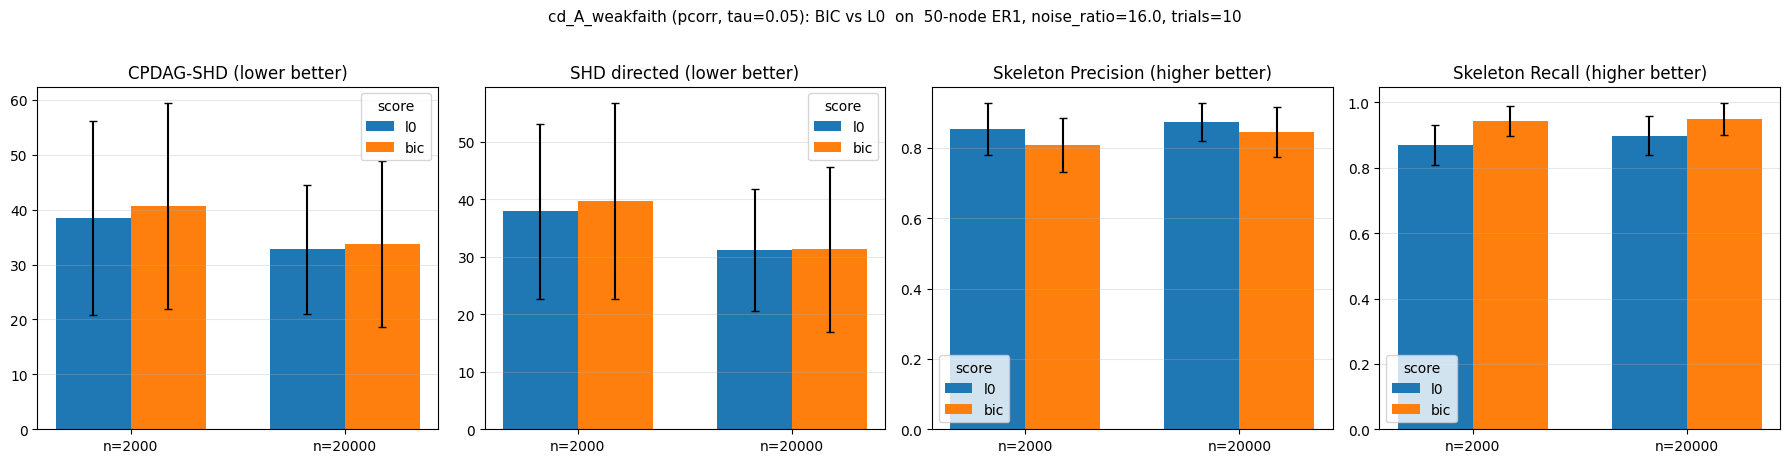

In [5]:
metrics_to_plot = [
    ('cpdag_shd_mean', 'cpdag_shd_std', 'CPDAG-SHD (lower better)'),
    ('shd_mean',       'shd_std',       'SHD directed (lower better)'),
    ('sk_p_mean',      'sk_p_std',      'Skeleton Precision (higher better)'),
    ('sk_r_mean',      'sk_r_std',      'Skeleton Recall (higher better)'),
]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(4.5 * len(metrics_to_plot), 4.5))
x_pos = np.arange(len(CFG['n_list']))
width = 0.35

for ax, (mcol, scol, title) in zip(axes, metrics_to_plot):
    for i, score in enumerate(SCORE_VARIANTS):
        sub = df_summary[df_summary['score'] == score].set_index('n_samples').reindex(CFG['n_list'])
        offset = (i - 0.5) * width
        ax.bar(x_pos + offset, sub[mcol].values, width=width,
               yerr=sub[scol].values, label=score, capsize=3)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'n={n}' for n in CFG['n_list']])
    ax.set_title(title)
    ax.grid(alpha=0.3, axis='y')
    ax.legend(fontsize=10, title='score')

fig.suptitle(
    f"cd_A_weakfaith (pcorr, tau={CFG['wf_tau']}): BIC vs L0  on  "
    f"{CFG['d']}-node ER1, noise_ratio={CFG['noise_ratio']}, trials={CFG['trials']}",
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.show()

## 6. 结论速读

- 看 `cpdag_shd_mean`：BIC 与 L0 哪个更低？
- 看 `n_edges_est`（真值=5）：BIC 因 `lambda_eff = log(n)/n` 在 n=2000 时 ≈ 3.8e-3，n=20000 时 ≈ 5e-4，**远小于 L0 的 0.2** → BIC 倾向估更稠密的图
- 看随 n 的变化：BIC 的惩罚自动随 n 调，**理论上 n 越大越接近真模型**；L0 的 `λ=0.2` 是固定的，n 变大时不一定最优
- 看 `actual_T`：BIC 收敛是否更慢/更快？